## Creating a Logistic Regression Model

### Discovery

You have been tasked with trying to determine if there is a linear relationship between the patients cholesterol levels and other characteristics. You will use a linear regression model to establish if any relationship exists and if so, how cholesterol levels are impacted by other chemicals, substances and health measures. 

First we will import the required modules. They are:
- pandas
- seaborn
- statsmodels.api
- sklearn.model_selection - train_test_split
- sklearn.metrics - confusion_matrix
- matplotlib.pyplot

In [18]:
# Import required modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

--- 
### Data preparation
Import the diabetes dataset and restrict to the required columns.

In [19]:
# Import the first dataset and set the date as the index
df = pd.read_csv("teen mental health data/mental_health_data.csv")
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [21]:
df["depression"] = df["depression_label"].astype(bool)

In [ ]:
df = df.drop({"gender","platform_usage", "social_interaction_level","depression_label"}, axis = 1)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   daily_social_media_hours  1200 non-null   float64
 2   sleep_hours               1200 non-null   float64
 3   screen_time_before_sleep  1200 non-null   float64
 4   academic_performance      1200 non-null   float64
 5   physical_activity         1200 non-null   float64
 6   stress_level              1200 non-null   int64  
 7   anxiety_level             1200 non-null   int64  
 8   addiction_level           1200 non-null   int64  
 9   depression                1200 non-null   bool   
dtypes: bool(1), float64(5), int64(4)
memory usage: 85.7 KB


--- 
### Model planning
You will now need to understand which variables can help you determine whether we will hit the predetermined threshold or not. To begin with, we need to understand our data a little more. Lets get the mean and median oil price.  

In [24]:
# Create aggregate table on the true/false column. Find the mean value. Variables should have distinct differences in the mean.
df.groupby("depression").mean()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level
depression,,,,,,,,,
False,15.924722,4.478785,6.494183,1.742258,2.990248,1.016168,5.365269,5.557742,5.571429
True,16.064516,6.719355,4.761290,1.667742,2.995484,0.951613,8.483871,8.612903,5.322581


Next create a box plot with an independent vairable and your target variable (your true/false column).

C:\Users\CharlesArthur\AppData\Local\Temp\ipykernel_20552\4267490688.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig1 = sns.catplot(


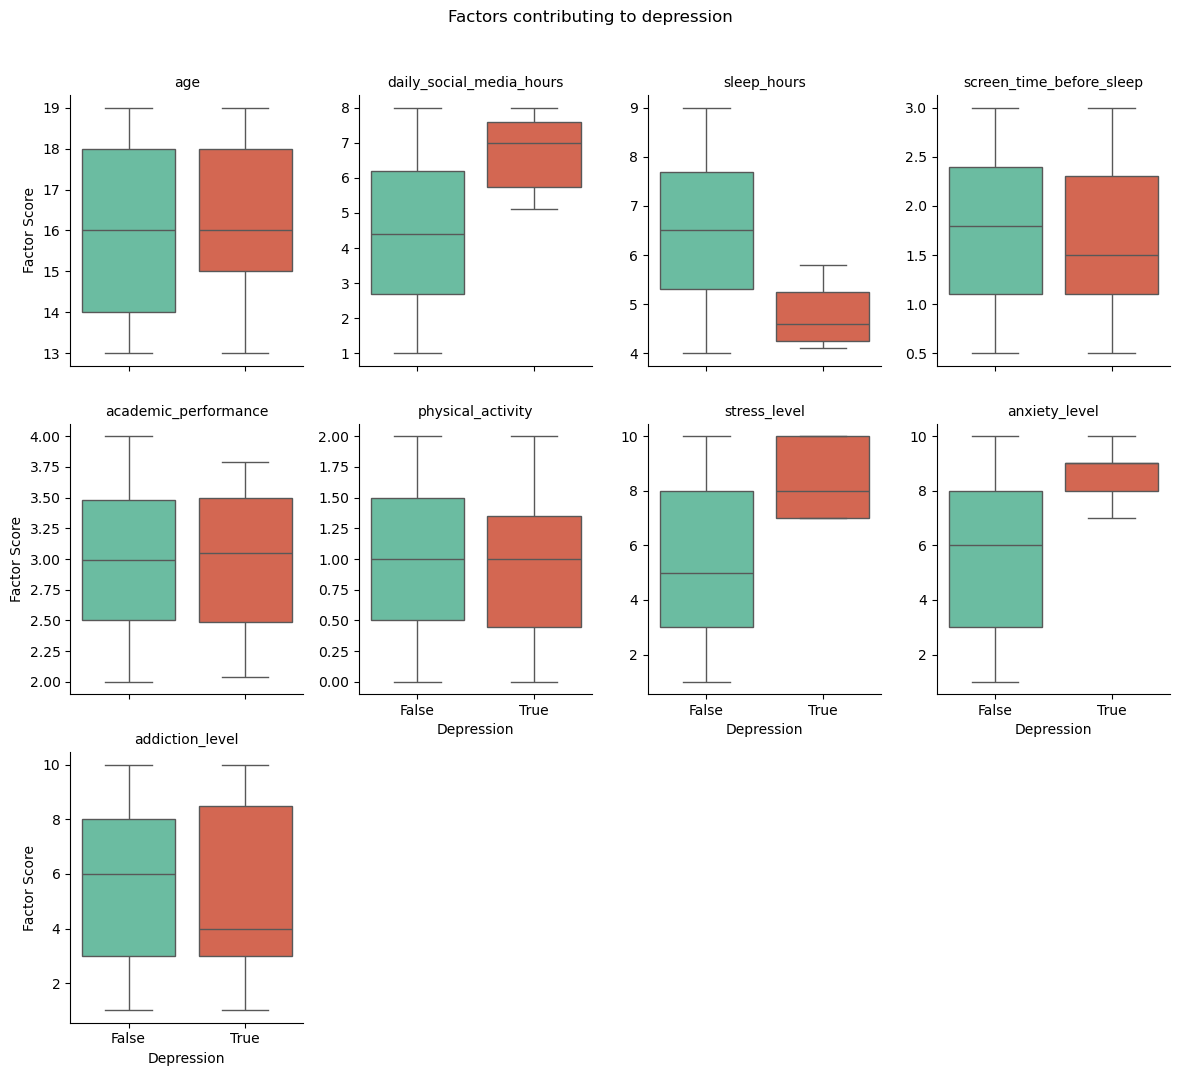

In [25]:
# Melt the dataframe for multi-variable box plot
features = ["age","daily_social_media_hours","sleep_hours","screen_time_before_sleep","academic_performance","physical_activity","stress_level","anxiety_level","addiction_level"]
plot_df = df.melt(id_vars="depression", value_vars=features)

fig1 = sns.catplot(
    x="depression",
    y="value",
    col="variable",
    kind="box",
    data=plot_df,
    col_wrap=4,
    height=3.5,
    aspect=0.85,
    palette={'False': "#5DCAA5", 'True': "#E8593C"},
    showfliers=False,
    sharey=False
)
fig1.set_titles(col_template="{col_name}")
fig1.set_axis_labels("Depression", "Factor Score")
fig1.figure.suptitle("Factors contributing to depression", y=1.02)
plt.tight_layout()
plt.show()

Finally, a correlation matrix will help us to see if there is a strong relationship between our dependent and independent variable. 

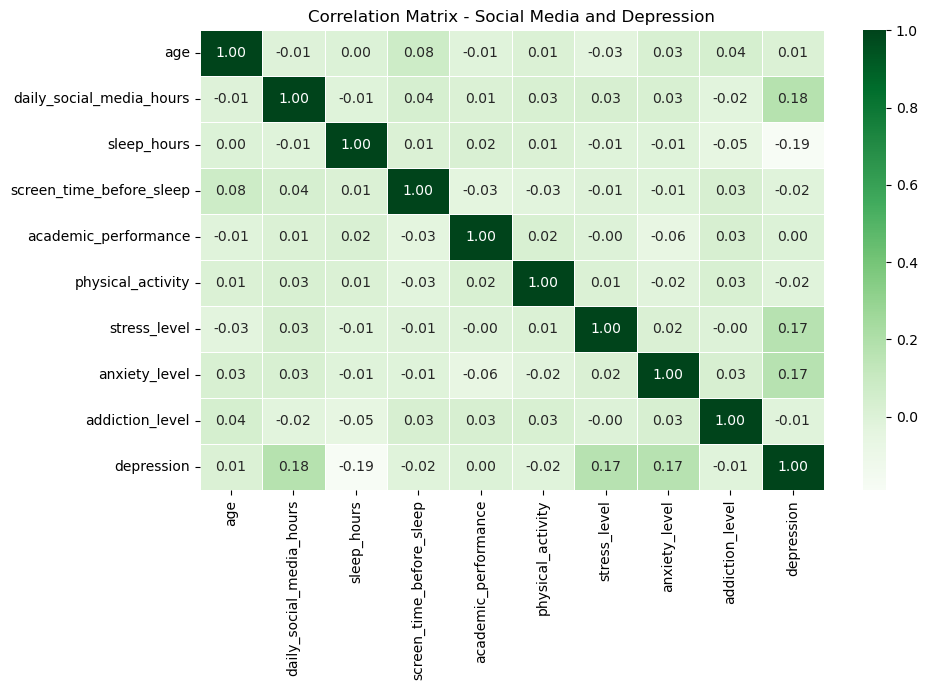

In [26]:
# Create a correlation matrix to demonstrate relationships between our variables
corr = df.corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Greens", ax=ax,
            linewidths=0.4, linecolor="white")
ax.set_title("Correlation Matrix - Social Media and Depression")
plt.tight_layout()
plt.show()

---
### Building the model
Split the data into training and test datasets - include the random_state argument:<br>
random_state = 25

In [27]:
# Split the data into train and test samples
train, test = train_test_split(df,random_state=25)

Set both the independent variable and dependent variable - remember to check they are set correctly. Don't forget to add a constant to your independent variables. 

In [28]:
# Set the dependent variable and validate
dep = train["depression"]
dep.head()

150    False
541    False
121    False
513    False
243    False
Name: depression, dtype: bool

In [29]:
# Set the independent variable and validate
ind = train[["daily_social_media_hours","sleep_hours","stress_level","anxiety_level"]]
ind.head()

,daily_social_media_hours,sleep_hours,stress_level,anxiety_level
150,4.1,6.4,7,3
541,7.8,7.4,10,1
121,4.0,8.1,4,8
513,4.7,5.1,8,9
243,7.8,4.7,8,3


In [30]:
# Remember to add the constant 
ind = sm.add_constant(ind)
ind.head()

,const,daily_social_media_hours,sleep_hours,stress_level,anxiety_level
150,1.0,4.1,6.4,7,3
541,1.0,7.8,7.4,10,1
121,1.0,4.0,8.1,4,8
513,1.0,4.7,5.1,8,9
243,1.0,7.8,4.7,8,3


Now generate the logistic regression model along with a summary output. 

In [31]:
# Fit the model and produce the summary
model = sm.Logit(dep,ind).fit()
model.summary()

# Model 1 with age and SBP  - PRS 0.2374
# Model 2 without - PRS 0.2344

Optimization terminated successfully.
         Current function value: 0.039877
         Iterations 12


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             depression   No. Observations:                  900
Model:                          Logit   Df Residuals:                      895
Method:                           MLE   Df Model:                            4
Date:                Wed, 10 Jun 2026   Pseudo R-squ.:                  0.6757
Time:                        12:11:33   Log-Likelihood:                -35.889
converged:                       True   LL-Null:                       -110.66
Covariance Type:            nonrobust   LLR p-value:                 2.548e-31
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                      -11.5995      3.183     -3.644      0.000     -17.838      -5.361
daily_social_media_hours     1.1783      0.274      4.306      0.000       0.642       1.715
sleep_hours                 -2.0648      0.435     -4.742      0.000      -2.918      -1.211
stress_level                 0.8629      0.193      4.480      0.000       0.485       1.240
anxiety_level                0.7614      0.186      4.090      0.000       0.397       1.126
============================================================================================

Possibly complete quasi-separation: A fraction 0.59 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

--- 
### Communicating the results. 
You will now analyse the model and communicate the results. What do the following outputs tell you about the model

- Pseudo R-Squared:
- P-Value:
- Coefficient:

In [32]:
# Use the model to predict which dates we are likely to hit high oil prices. Check the output.
predictions = model.predict(ind) >= 0.5
#pred_num = model.predict(ind)
predictions.head()
#pred_num.head()

150    False
541    False
121    False
513    False
243    False
dtype: bool

Once we have our preductions - we can use these to create a confusion matrix, which will help us to assess the model quality. 

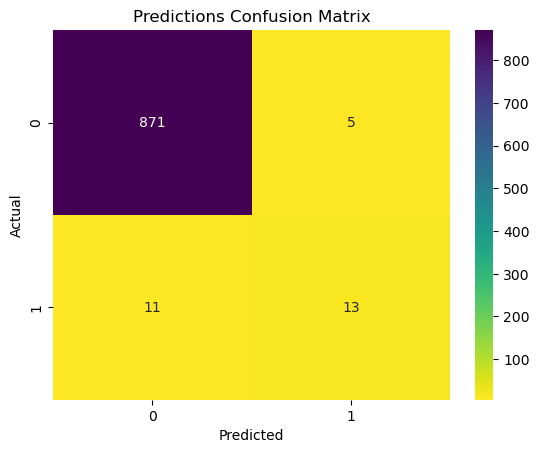

In [33]:
# Generate a confusion matrix to test the model
conf_mat = confusion_matrix(dep, predictions)

# (Optional) Generate the confusion matrix as a heatmap
confusion_mat_heatmap = sns.heatmap(conf_mat, annot = True, cmap = 'viridis_r', fmt='g')

# (Optional) set x and y labels, and create a title
confusion_mat_heatmap.set_xlabel('Predicted')
confusion_mat_heatmap.set_ylabel('Actual')
confusion_mat_heatmap.set_title("Predictions Confusion Matrix")
plt.show()

**Basic Terminology**

**True Positives (TP)** is 65: The model correctly predicted a large purchase. (Bottom right)

**True Negatives (TN)** is 2603: The model correctly predicted that it wont be a large purchase. (Top left)

**False Positives (FP)** is 253: The model incorrectly predicted a large purchase. (Top right)

**False Negatives (FN)** is 306: The model incorrectly predicted it wont be a large purchase. (Bottom left)

In [34]:
# Check incorrectly predicted rows
output = model.predict(ind) >= 0.5
train["predicted"] = output
train = train[["LDL","high_chol","predicted"]]
inc_diff = train[train["high_chol"] != train["predicted"]]
inc_diff.head()
inc_diff["LDL"].median()

KeyError: "['LDL', 'high_chol'] not in index"

In [ ]:
# Test the model 
dep_test = test["high_chol"]
ind_test = test[["LDL"]]
ind_test = sm.add_constant(ind_test)

# Produce the output and save to a dataframe column - then validate
output = model.predict(ind_test) >= 0.5
num_ouput = model.predict(ind_test)
test["predicted"] = output
test["numeric_predicted"] = num_ouput

# (Optional) Create a dataframe where only incorrect predictions are displayed
test = test[["LDL","high_chol","predicted","numeric_predicted"]]
inc_diff = test[test["high_chol"] != test["predicted"]]
inc_diff

,LDL,high_chol,predicted,numeric_predicted
1096,4.760000,True,False,0.465250
2859,4.110000,True,False,0.258470
4229,4.860753,False,True,0.500639
1297,3.790000,True,False,0.181792
597,3.950000,True,False,0.217704
...,...,...,...,...
3068,4.860753,False,True,0.500639
3863,4.860753,False,True,0.500639
3110,4.860753,False,True,0.500639
1292,4.360000,True,False,0.331341


In [ ]:
print(diabetes_df.loc[597])

Age            33
BMI          24.7
Chol         6.43
HDL          1.21
LDL          3.95
SBP           126
high_chol    True
Name: 597, dtype: object


<Axes: xlabel='LDL', ylabel='numeric_predicted'>

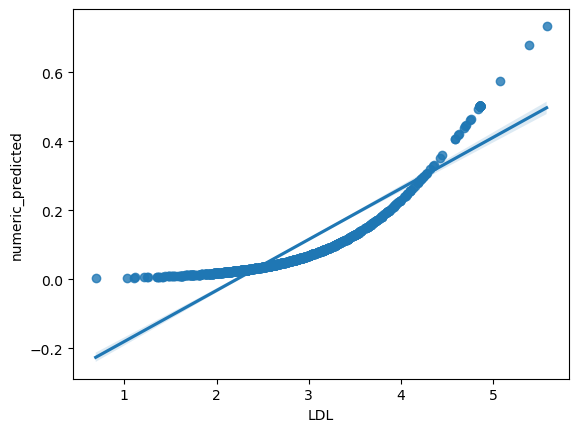

In [ ]:
sns.regplot(x = "LDL",
            y = "numeric_predicted",
            data = test)

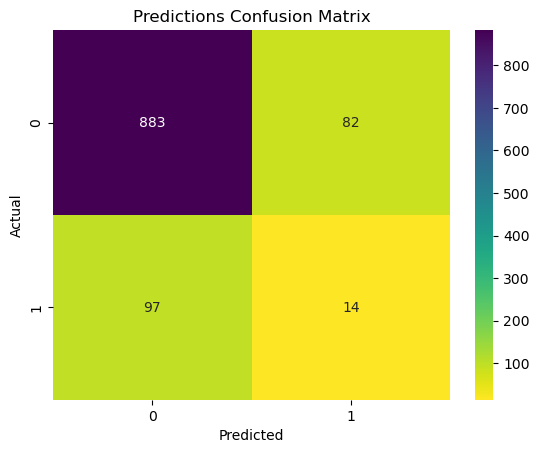

In [ ]:
# (Optional) Create a confusion matrix to display test results

tconf_mat = confusion_matrix(dep_test,output)
tconf_mat

# (Optional) Replicate the results as a heatmap as before:
tconfusion_mat_heatmap = sns.heatmap(tconf_mat, annot = True, cmap = 'viridis_r', fmt='g')

# (Optional) set x and y labels, and create a title
tconfusion_mat_heatmap.set_xlabel('Predicted')
tconfusion_mat_heatmap.set_ylabel('Actual')
tconfusion_mat_heatmap.set_title("Predictions Confusion Matrix")
plt.show()

---
### Stretch task
Create a new dataframe with some example data, and generate some predictions using your model.

--- 

In [ ]:
# Create a new dataframe

In [ ]:
# Generate predictions

In [ ]:
# Generate results in the dataframe, based on new dataset

--- 
### Operationalise
In the real world, this is where you would draft a report, deliver briefings, implement with automation on production level servers, produce technical documentation and build this into your BAU process. This being a fictional company, the ever grateful management have granted you paid leave for all your hard work and have volunteered to take on this burden themselves. Congratulations and well done!